In [8]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data.csv")
print("First look at the data:")
display(df.head())

# Drop unnecessary columns
print("\nChecking for weird columns...")
df = df.drop(['Unnamed: 32', 'id'], axis=1)
print("Columns after cleanup:", df.columns.tolist())


First look at the data:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Checking for weird columns...
Columns after cleanup: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [9]:

# For classification (B vs M)
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

reg_target = 'area_mean'
X_reg = df.drop(['diagnosis', reg_target], axis=1)
y_reg = df[reg_target]

print("Class balance:")
print(df['diagnosis'].value_counts())
print("\nTumor size stats:")
print(y_reg.describe())


Class balance:
diagnosis
0    357
1    212
Name: count, dtype: int64

Tumor size stats:
count     569.000000
mean      654.889104
std       351.914129
min       143.500000
25%       420.300000
50%       551.100000
75%       782.700000
max      2501.000000
Name: area_mean, dtype: float64


In [10]:
#Train-Test splits

from sklearn.model_selection import train_test_split

# Classification split
X_class = df.drop('diagnosis', axis=1)
y_class = df['diagnosis']
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

# Regression split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

print("Classification splits:", X_train_class.shape, X_test_class.shape)
print("Regression splits:", X_train_reg.shape, X_test_reg.shape)


Classification splits: (455, 30) (114, 30)
Regression splits: (455, 29) (114, 29)


In [11]:
#Scaling Features

from sklearn.preprocessing import StandardScaler

# For classification
scaler_class = StandardScaler()
X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

# For regression
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print("Example scaled values (classification):")
print(X_train_class_scaled[0][:5])  # Peek at first sample's first 5 features


Example scaled values (classification):
[-1.44075296 -0.43531947 -1.36208497 -1.1391179   0.78057331]


Initial Classification Performance:
Accuracy: 0.97
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



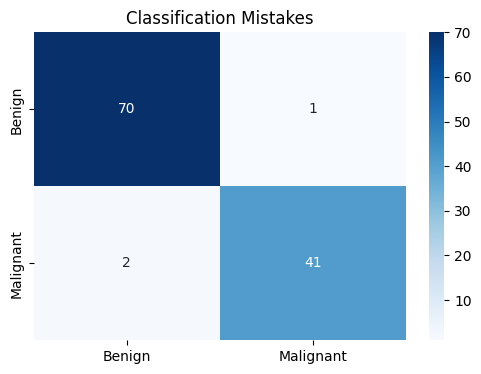

In [12]:
# Classification Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logreg = LogisticRegression(max_iter=1000)  # Increased iterations for convergence
logreg.fit(X_train_class_scaled, y_train_class)
y_pred_class = logreg.predict(X_test_class_scaled)

print("Initial Classification Performance:")
print(f"Accuracy: {accuracy_score(y_test_class, y_pred_class):.2f}")
print(classification_report(y_test_class, y_pred_class))

# Confusion matrix visualization
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_class, y_pred_class), 
            annot=True, fmt='g', cmap='Blues',
            xticklabels=['Benign', 'Malignant'], 
            yticklabels=['Benign', 'Malignant'])
plt.title('Classification Mistakes')
plt.show()


Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params found: {'C': 10, 'epsilon': 0.05, 'kernel': 'linear'}

Regression Performance:
MSE: 781.54
R²: 0.99


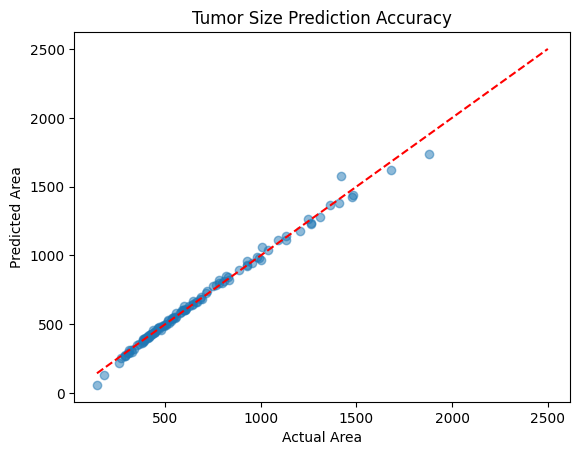

In [13]:


from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

param_grid = {
    'kernel': ['rbf', 'linear'],  # Skip poly for now to save time
    'C': [0.1, 1, 10],
    'epsilon': [0.05, 0.1]
}

grid_search = GridSearchCV(SVR(), param_grid, cv=3, verbose=1, n_jobs=-1)
grid_search.fit(X_train_reg_scaled, y_train_reg)

print("\nBest params found:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred_reg = best_model.predict(X_test_reg_scaled)

print("\nRegression Performance:")
print(f"MSE: {mean_squared_error(y_test_reg, y_pred_reg):.2f}")
print(f"R²: {r2_score(y_test_reg, y_pred_reg):.2f}")

# Actual vs Predicted plot
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'r--')
plt.title('Tumor Size Prediction Accuracy')
plt.xlabel('Actual Area')
plt.ylabel('Predicted Area')
plt.show()


Top features influencing classification:


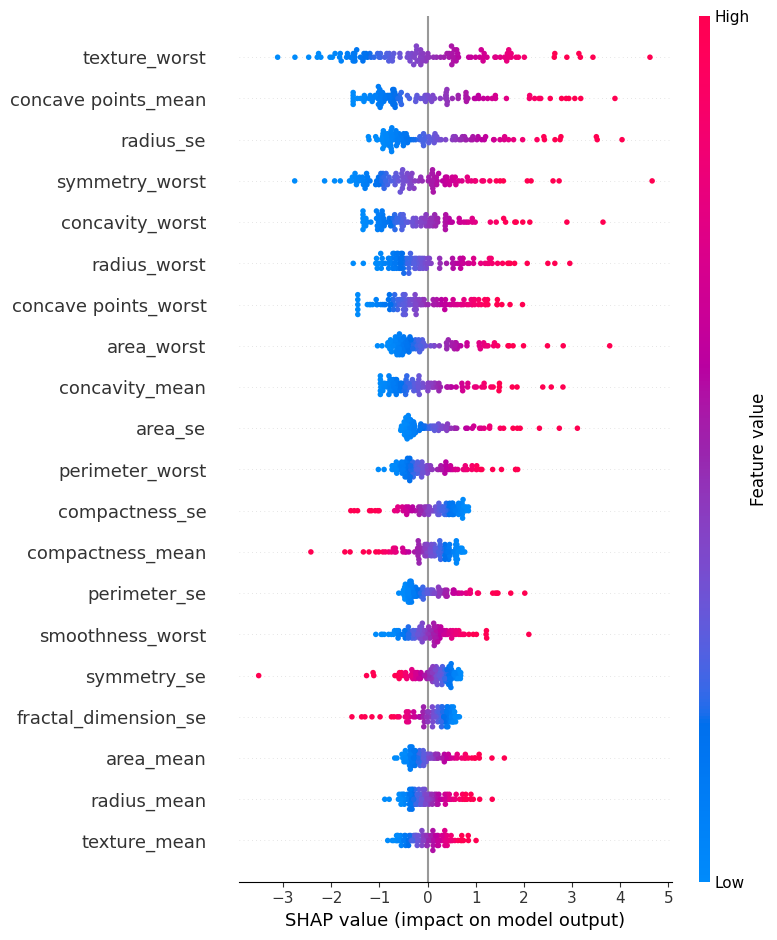

In [14]:

# SHAP for classification model 

explainer = shap.Explainer(logreg, X_train_class_scaled)
shap_values = explainer(X_test_class_scaled)

print("Top features influencing classification:")
shap.summary_plot(shap_values, X_test_class_scaled, feature_names=X_class.columns)
plt.show()


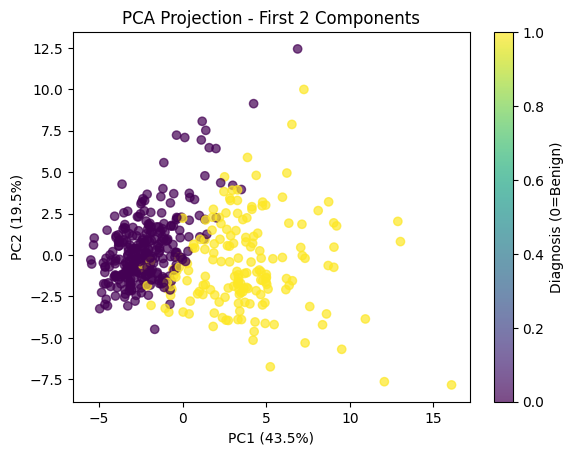

Variance explained by components: [0.43502782 0.19500007]


In [15]:
#Dimensionality Reduction (PCA to see if we can reduce features)


from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_class_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train_class, cmap='viridis', alpha=0.7)
plt.colorbar(label='Diagnosis (0=Benign)')
plt.title('PCA Projection - First 2 Components')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.show()

print("Variance explained by components:", pca.explained_variance_ratio_)


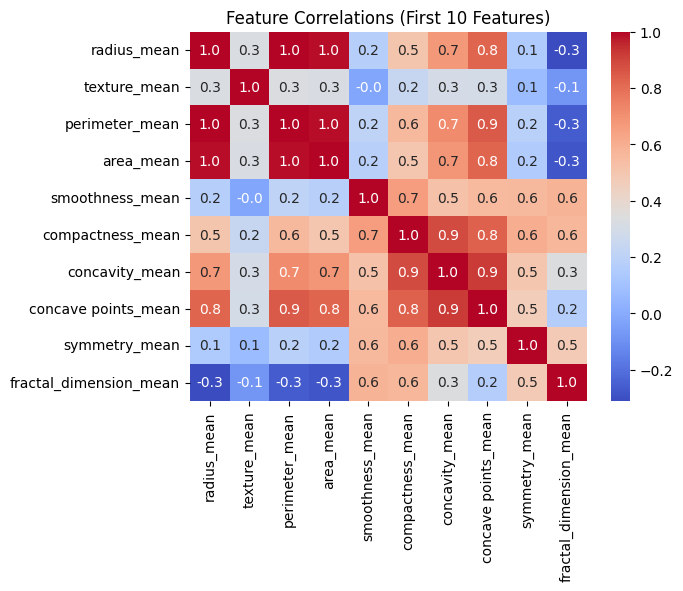

In [16]:
#Feature Relationships

top_features = X_class.columns[:10]  # Just the first 10 for clarity
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Feature Correlations (First 10 Features)')
plt.show()

# Full correlation matrix comment (but not plotted here)
